# Lab cleanup Navigators


_Imports and Helpers_


In [1]:
import sys
print(sys.executable)

from navigator_types import SystematicNavigator
from navigators import BousPath, SkeletonPath, SpanningTreePath
import matplotlib.pyplot as plt
import utils as ut
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import ipywidgets as widgets
from IPython.display import display


def show_imgs(imgs, labels):
    n = len(imgs)
    fig, ax = plt.subplots(1, n, figsize=(6*n, 6))

    if n == 1:
        ax = [ax]

    for i in range(n):
        img = cv2.normalize(imgs[i], None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
        ax[i].imshow(img, cmap="gray")
        ax[i].set_title(labels[i])
        ax[i].axis("off")

    plt.tight_layout()
    plt.show()

/home/matth/Desktop/BEP/ros2_humble_dev/lcr/src/mirte_lc/.venv/bin/python


## Setup

In order to demonstrate the different navigators, a map must first be loaded into the notebook. \
We use a map provided by the [mirte navigation](https://github.com/MartijnWisse/mirte_navigation) ros2 package


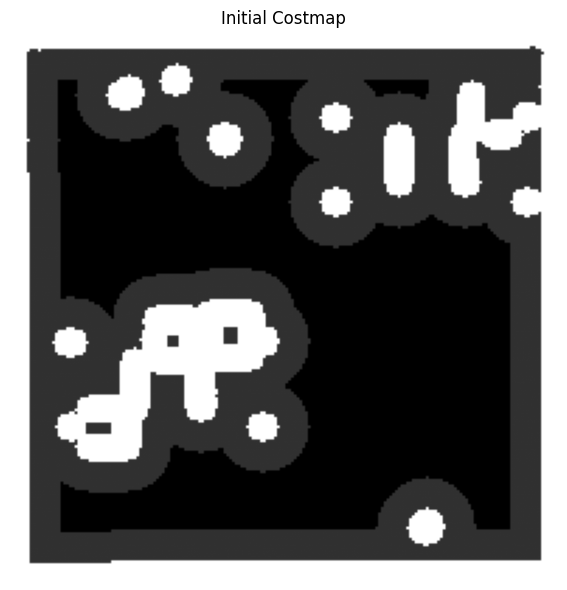

In [3]:
path = "maps/lc_costmap.pgm"
map_img = cv2.bitwise_not(cv2.imread(path, cv2.IMREAD_UNCHANGED))
show_imgs([map_img], ['Initial Costmap'])

## Systematic Navigator

Each defined navigator is a derived class of `SystematicNavigator`, a metaclass encompassing all navigators \
that plan coverage paths over the whole free space area. Standard for the derived classes is that they \
update their internal map and as a result plan a path over this map.

```update_map()``` first takes the costmap and, given a threshold, sets the free space to [0, 0, 0] and occupied space [255, 255, 255]. \
It then uses ```opencv.findContours()``` to find the free space boundaries and saves these as contours.



Testing if contour [(np.float64(1.425), np.float64(-4.025)), (np.float64(1.625), np.float64(-3.825)), (np.float64(1.625), np.float64(-3.7750000000000004)), (np.float64(1.725), np.float64(-3.7750000000000004)), (np.float64(1.7750000000000001), np.float64(-3.825)), (np.float64(1.975), np.float64(-3.825)), (np.float64(2.025), np.float64(-3.875)), (np.float64(2.075), np.float64(-3.825)), (np.float64(2.275), np.float64(-3.825)), (np.float64(2.325), np.float64(-3.7750000000000004)), (np.float64(2.375), np.float64(-3.7750000000000004)), (np.float64(2.4250000000000003), np.float64(-3.725)), (np.float64(2.475), np.float64(-3.725)), (np.float64(2.475), np.float64(-3.7750000000000004)), (np.float64(2.5250000000000004), np.float64(-3.825)), (np.float64(2.5250000000000004), np.float64(-4.025)), (np.float64(1.425), np.float64(-4.025))] points is inside contour [(np.float64(-4.025), np.float64(-4.025)), (np.float64(-3.975), np.float64(-0.17500000000000002)), (np.float64(-3.075), np.float64(0.17500000

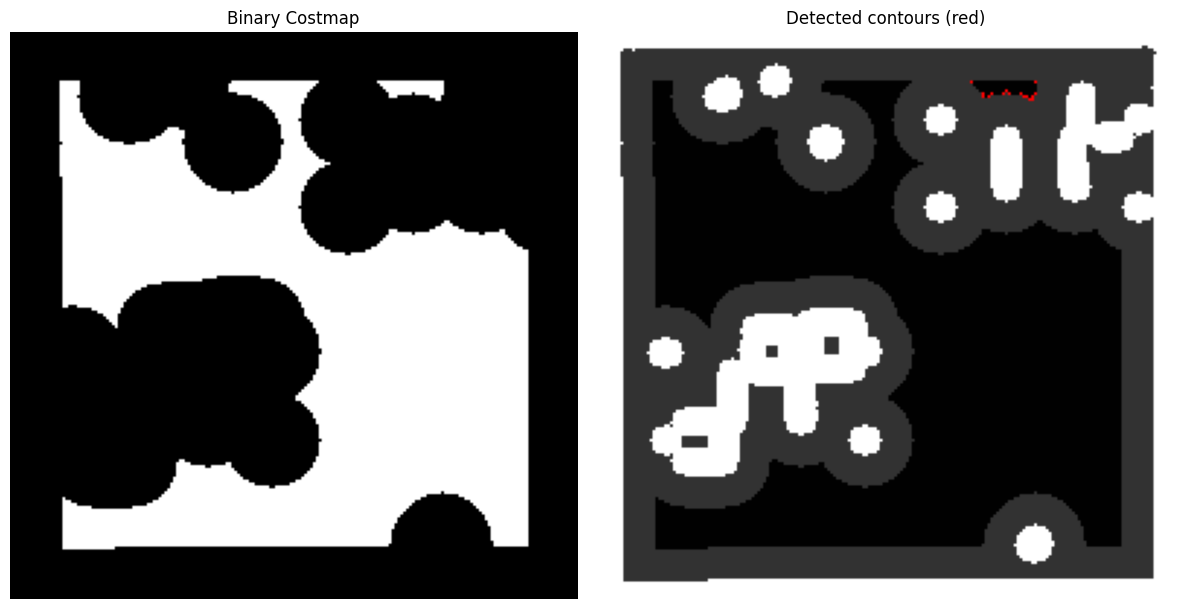

In [4]:
navigator = SystematicNavigator()

navigator.update_map(map_img)
contours = navigator.contours
print(len(contours))
color_img = cv2.cvtColor(map_img, cv2.COLOR_GRAY2RGB)
contour_img = cv2.drawContours(color_img, contours[1], -1, (255, 0, 0), 1)

show_imgs([navigator.binary_costmap, contour_img], 
         ['Binary Costmap', 'Detected contours (red)'])

## BousPath
The first navigator that will be covered is a Boustropedon based Coverage planner. \
This navigator plans in two steps:
- Decomposition
- Swath Generation

### Boustropedon Cellular Decomposition

In [ ]:
# Update internal map
navigator = BousPath()
navigator.update_map(map_img)
pixel_cells = []
cells = []
display_cells = []
color_img = cv2.cvtColor(map_img.copy(), cv2.COLOR_GRAY2RGB)
# Perform Boustropethan Celular Decomposition
for group in  navigator.polymap:
    display_cells.extend(navigator.bcd(group))
    cells.append(navigator.bcd(group))
    pixel_cells.extend(
        navigator.world_to_pixel(poly.exterior.coords)
        for poly in cells
    )  

decomp_img = cv2.drawContours(color_img, pixel_cells, -1, (0, 255, 0), 1)
show_imgs(
    [decomp_img],
    ['Decomposed Map']
)

Testing if contour [(np.float64(1.425), np.float64(-4.025)), (np.float64(1.625), np.float64(-3.825)), (np.float64(1.625), np.float64(-3.7750000000000004)), (np.float64(1.725), np.float64(-3.7750000000000004)), (np.float64(1.7750000000000001), np.float64(-3.825)), (np.float64(1.975), np.float64(-3.825)), (np.float64(2.025), np.float64(-3.875)), (np.float64(2.075), np.float64(-3.825)), (np.float64(2.275), np.float64(-3.825)), (np.float64(2.325), np.float64(-3.7750000000000004)), (np.float64(2.375), np.float64(-3.7750000000000004)), (np.float64(2.4250000000000003), np.float64(-3.725)), (np.float64(2.475), np.float64(-3.725)), (np.float64(2.475), np.float64(-3.7750000000000004)), (np.float64(2.5250000000000004), np.float64(-3.825)), (np.float64(2.5250000000000004), np.float64(-4.025)), (np.float64(1.425), np.float64(-4.025))] points is inside contour [(np.float64(-4.025), np.float64(-4.025)), (np.float64(-3.975), np.float64(-0.17500000000000002)), (np.float64(-3.075), np.float64(0.17500000

IndexError: list index out of range

### Boustrophedon Path Generation

In [ ]:
paths = []
for cell in cells:
    bous_paths = navigator.bous_path(cells)
    paths.append(bous_paths)

swath_img = cv2.cvtColor(map_img, cv2.COLOR_GRAY2RGB)

for path in paths:
    pts = np.array(navigator.world_to_pixel_path(path), dtype=np.int32)

    swath_img = cv2.polylines(
        swath_img,
        [pts],
        isClosed=False,
        color=(0, 255, 255),
        thickness=1
    )
show_imgs(
    [swath_img],
    ['Generated Paths']
)


Number of cells: 18
generating full trajectory


## SkeletonPath

The `SkeletonPath` planner is a topology-based coverage planner that generates navigation paths using the morphological skeleton of the environment.

Unlike the `BousPath` planner, which decomposes the free space into sweepable cells, the skeleton planner reduces the free space to a graph-like centerline representation. This representation preserves the connectivity of the environment while simplifying path planning.

The implementation is inspired by recent work in morphology-based exploration and autonomous navigation.

---

### Planner Initialization

The planner can be initialized similarly to the other navigators:

In [3]:
navigator = SkeletonPath()

navigator.update_map(map_img)

Testing if contour [(np.float64(1.425), np.float64(-4.025)), (np.float64(1.625), np.float64(-3.825)), (np.float64(1.625), np.float64(-3.7750000000000004)), (np.float64(1.725), np.float64(-3.7750000000000004)), (np.float64(1.7750000000000001), np.float64(-3.825)), (np.float64(1.975), np.float64(-3.825)), (np.float64(2.025), np.float64(-3.875)), (np.float64(2.075), np.float64(-3.825)), (np.float64(2.275), np.float64(-3.825)), (np.float64(2.325), np.float64(-3.7750000000000004)), (np.float64(2.375), np.float64(-3.7750000000000004)), (np.float64(2.4250000000000003), np.float64(-3.725)), (np.float64(2.475), np.float64(-3.725)), (np.float64(2.475), np.float64(-3.7750000000000004)), (np.float64(2.5250000000000004), np.float64(-3.825)), (np.float64(2.5250000000000004), np.float64(-4.025)), (np.float64(1.425), np.float64(-4.025))] points is inside contour [(np.float64(-4.025), np.float64(-4.025)), (np.float64(-3.975), np.float64(-0.17500000000000002)), (np.float64(-3.075), np.float64(0.17500000

### Reading and Skeletonizing the Map

The skeleton planner generates a morphological skeleton using the `read()` method

Internally, the planner:
1. fills the free-space contours,
2. skeletonizes the free-space region,
3. extracts skeleton pixels,
4. converts them into Cartesian waypoints.

The generated waypoints are stored in `waypoints`

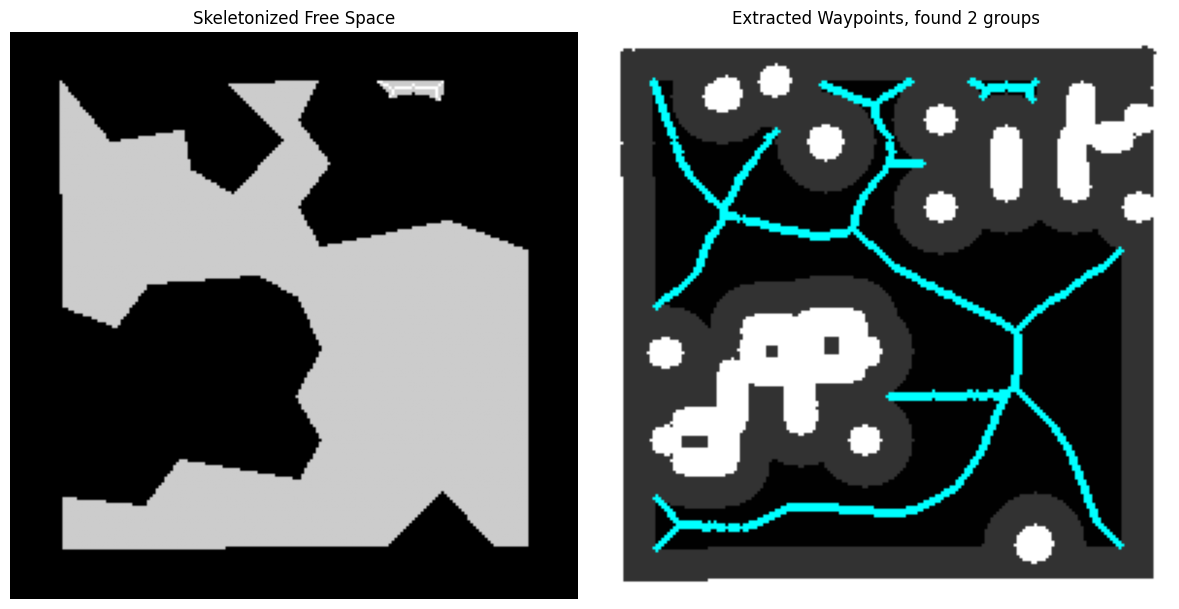

In [4]:
navigator.read()

skeleton_img = cv2.addWeighted(
    navigator.contour_map,
    0.8,
    navigator.skeleton_map,
    0.2,
    0,
)

# Convert grayscale map to RGB so we can draw colored points
waypoint_img = cv2.cvtColor(map_img.copy(), cv2.COLOR_GRAY2RGB)

# Convert waypoint coordinates (meters) back to image pixels
pts = []
for group in navigator.waypoint_groups:
    for point in group:
        x_world, y_world = point

        # Convert world -> image coordinates
        px = int((x_world / navigator.map_resolution) + navigator.origin[1])
        py = int((y_world / navigator.map_resolution) + navigator.origin[0])

        pts.append((px, py))

# Draw every waypoint
for pt in pts:
    cv2.circle(
        waypoint_img,
        pt,
        radius=1,
        color=(0, 255, 255),
        thickness=-1
    )

show_imgs(
    [skeleton_img, waypoint_img],
    ['Skeletonized Free Space', f'Extracted Waypoints, found {len(navigator.waypoint_groups)} groups']
)

### Path Planning

After the waypoints have been generated, they are then sampled and ordered. \
The algorithm does this by first constructing a graph representation of the skeleton tree. \
The waypoints then become graph nodes. Edges are generated between the nodes with a certain distance threshold \
finding leaf nodes, meaning nodes with only one connection (green),

To efficiently identify neighboring points, a k-d tree is used for spatial indexing. \
Starting from the closest waypoint to the robot, the algorithm recursively explores nearby nodes and connects them within the graph,

Leaf nodes are then identified in the tree, (nodes with one connection).

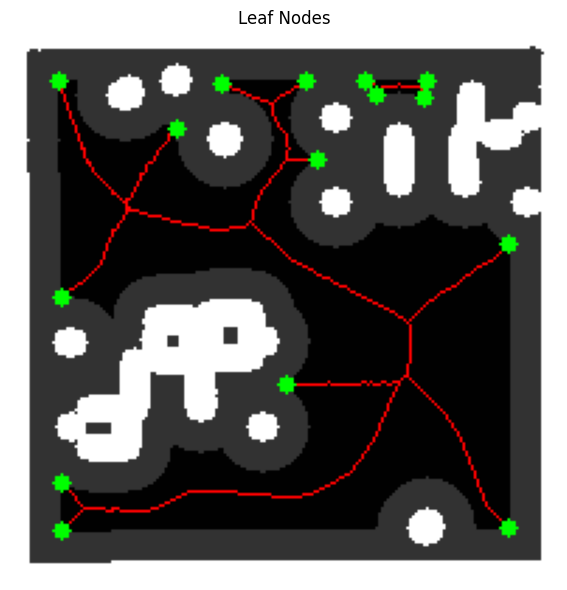

In [5]:
paths = []

graph_img = cv2.cvtColor(map_img.copy(), cv2.COLOR_GRAY2RGB)

graphs = []
leaf_nodes = []   # will store (graph, node_id)

for waypoints in navigator.waypoint_groups:
    graph = navigator.set_waypoints(waypoints, navigator.resolution) 
    graphs.append(graph)

    # ---- draw edges (per graph, correct scope) ----
    for n1, n2 in graph.edges:

        p1 = graph.nodes[n1]['pos']
        p2 = graph.nodes[n2]['pos']

        x1 = int((p1[0] / navigator.map_resolution) + navigator.origin[1])
        y1 = int((p1[1] / navigator.map_resolution) + navigator.origin[0])

        x2 = int((p2[0] / navigator.map_resolution) + navigator.origin[1])
        y2 = int((p2[1] / navigator.map_resolution) + navigator.origin[0])

        cv2.line(graph_img, (x1, y1), (x2, y2), (255, 0, 0), 1)

        # ---- collect leaf nodes WITH GRAPH CONTEXT ----
        local_leaves = navigator.find_leaf_nodes(graph)
        leaf_nodes.extend([(graph, n) for n in local_leaves])


# ---- draw leaf nodes (FIXED: use correct graph) ----
for graph, node in leaf_nodes:

    point = graph.nodes[node]['pos']

    px = int((point[0] / navigator.map_resolution) + navigator.origin[1])
    py = int((point[1] / navigator.map_resolution) + navigator.origin[0])

    cv2.circle(
        graph_img,
        (px, py),
        radius=3,
        color=(0, 255, 0),
        thickness=-1
    )


show_imgs([graph_img], ['Leaf Nodes'])

### Path Ordering

First the closest leaf node to the robot is found, this is the starting position. \
The planner traces a path along the tree and selects the shortest one to the next leaf node. \
It then appends these points to the path and sets this new leaf node as the current one and marks it as visited. \
The algorithm repeats this process untill all leaf nodes have been explored successfully.

graphs: 2, groups: 2


IntSlider(value=0, description='Waypoint:', layout=Layout(width='800px'), max=1064)

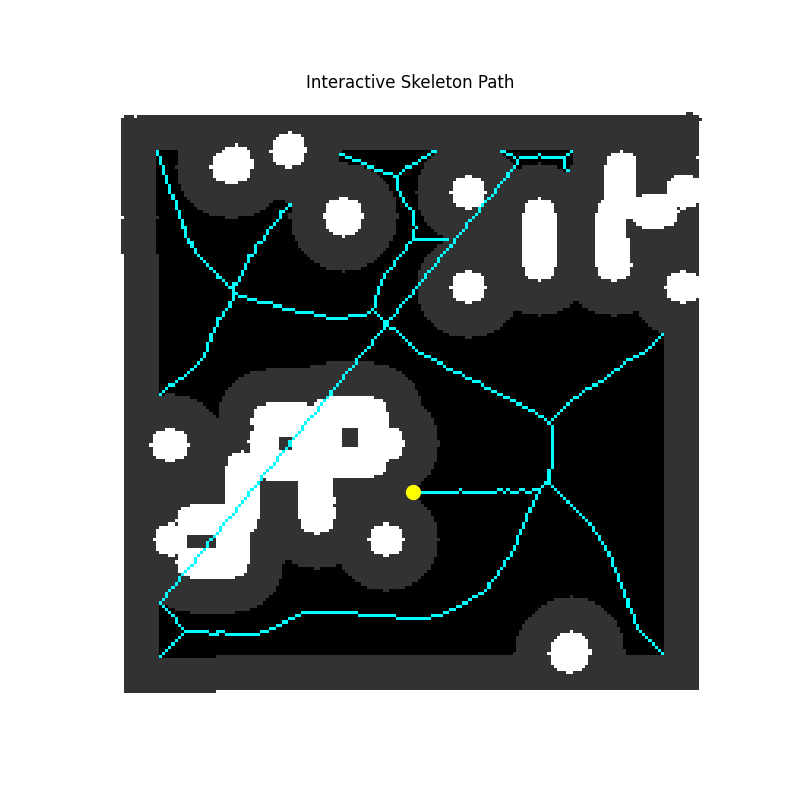

In [6]:
# Generate planner path
paths = []
start = np.array([0, 0])
print(f'graphs: {len(graphs)}, groups: {len(navigator.waypoint_groups)}')

for graph, waypoints in zip(graphs, navigator.waypoint_groups):
    path = navigator.plan_path(start, graph, waypoints)
    paths.append(path)
    start = path[-1]

# Interactive Jupyter widget slider for skeleton path

%matplotlib widget
import matplotlib.pyplot as plt
plt.ion()

import ipywidgets as widgets
from IPython.display import display

# --------------------------------------------------
# Convert path points to image pixels
# --------------------------------------------------

path_pixels = []
for path in paths:
    path_points = path


    for point in path_points:
        x_world, y_world = point

        px = int((x_world / navigator.map_resolution) + navigator.origin[1])
        py = int((y_world / navigator.map_resolution) + navigator.origin[0])

        path_pixels.append((px, py))

path_pixels = np.array(path_pixels)

# --------------------------------------------------
# Create visualization image
# --------------------------------------------------

path_img = cv2.cvtColor(map_img.copy(), cv2.COLOR_GRAY2RGB)

# Draw skeleton path
cv2.polylines(
    path_img,
    [path_pixels.astype(np.int32)],
    isClosed=False,
    color=(0, 255, 255),
    thickness=1
)

# --------------------------------------------------
# Create interactive figure
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(path_img)
ax.set_title("Interactive Skeleton Path")
ax.axis("off")

# Yellow moving dot
robot_dot, = ax.plot(
    path_pixels[0, 0],
    path_pixels[0, 1],
    'o',
    color='yellow',
    markersize=10
)

# --------------------------------------------------
# Slider widget
# --------------------------------------------------

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(path_pixels) - 1,
    step=1,
    description='Waypoint:',
    continuous_update=True,
    layout=widgets.Layout(width='800px')
)

# --------------------------------------------------
# Update function
# --------------------------------------------------

def update_robot(change):
    idx = change['new']

    x = path_pixels[idx, 0]
    y = path_pixels[idx, 1]

    robot_dot.set_data([x], [y])

    fig.canvas.draw()

slider.observe(update_robot, names='value')

display(slider)

plt.show()

# Spanning Tree Coverage Path

The spanning tree coverage path planner generates a path that covers the entire free space of the map \
by firs discretizing the free space into a grid and then adding nodes into each pixel. \
It then performs a depth-first traversal of the nodes, creating a tree. \
This tree is then circumnavigated to create a coverage path.

In [7]:
navigator = SpanningTreePath(scale=0.05)
navigator.update_map(map_img)


Testing if contour [(np.float64(1.425), np.float64(-4.025)), (np.float64(1.625), np.float64(-3.825)), (np.float64(1.625), np.float64(-3.7750000000000004)), (np.float64(1.725), np.float64(-3.7750000000000004)), (np.float64(1.7750000000000001), np.float64(-3.825)), (np.float64(1.975), np.float64(-3.825)), (np.float64(2.025), np.float64(-3.875)), (np.float64(2.075), np.float64(-3.825)), (np.float64(2.275), np.float64(-3.825)), (np.float64(2.325), np.float64(-3.7750000000000004)), (np.float64(2.375), np.float64(-3.7750000000000004)), (np.float64(2.4250000000000003), np.float64(-3.725)), (np.float64(2.475), np.float64(-3.725)), (np.float64(2.475), np.float64(-3.7750000000000004)), (np.float64(2.5250000000000004), np.float64(-3.825)), (np.float64(2.5250000000000004), np.float64(-4.025)), (np.float64(1.425), np.float64(-4.025))] points is inside contour [(np.float64(-4.025), np.float64(-4.025)), (np.float64(-3.975), np.float64(-0.17500000000000002)), (np.float64(-3.075), np.float64(0.17500000

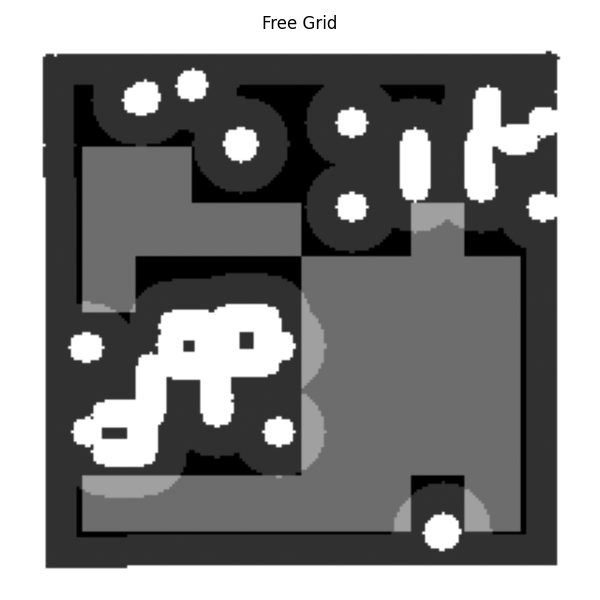

In [8]:
grid = navigator.sample_map(navigator.binary_costmap, navigator.scale)

overlay = cv2.resize(
    grid,
    (map_img.shape[1], map_img.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

result = cv2.addWeighted(
    map_img,
    0.7,
    overlay,
    0.3,
    0
)

show_imgs([result], 
         ['Free Grid'])



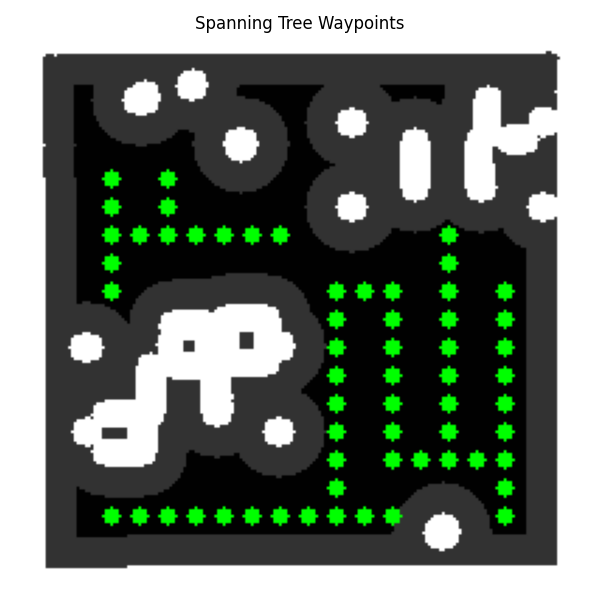

In [9]:
navigator.spanning_tree(grid)
navigator.generate_waypoints()

tree_field = cv2.cvtColor(map_img.copy(), cv2.COLOR_GRAY2RGB)
for point in navigator.tree_points:
    cv2.circle(
        tree_field,
        point,
        radius=3,
        color=(0, 255, 0),
        thickness=-1
    )

show_imgs([tree_field],
         ['Spanning Tree Waypoints'])


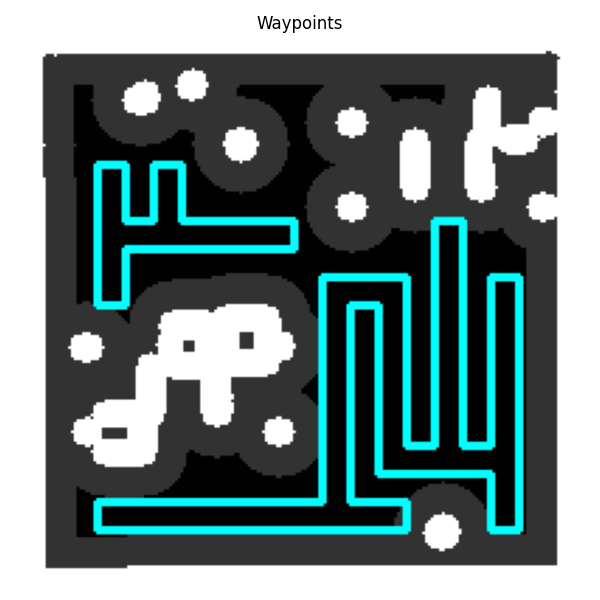

In [10]:
waypoint_img = cv2.cvtColor(map_img.copy(), cv2.COLOR_GRAY2RGB)
cv2.drawContours(
    waypoint_img,
    navigator.waypoints,
    -1,
    (0, 255, 255),
    2
)

show_imgs([waypoint_img],
         ['Waypoints'])